
SU(2) Yang-Mills in 2+1d  |  N=6  beta=3.0  g^2=1.333
Ncfg=150  thermal=80
Deformation: S_total = S_YM - s * log(lambda_min(M) + eps)

  s = -1080.00
  ----------
  Thermalisation acceptance: 0.20
    cfg 30/150  lmin=0.0152  accept=0.01
    cfg 60/150  lmin=0.0146  accept=0.00
    cfg 90/150  lmin=0.0143  accept=0.01
    cfg 120/150  lmin=0.0134  accept=0.00
    cfg 150/150  lmin=0.0130  accept=0.01
  m_gap/g^2 = 2.4174 ± 1.4818
  <lambda_min> = 0.0145 ± 0.0001
  <|Polyakov|> = 0.9794
  Mean acceptance = 0.01

  s = -432.00
  ----------
  Thermalisation acceptance: 0.51
    cfg 30/150  lmin=0.1297  accept=0.41
    cfg 60/150  lmin=0.1132  accept=0.39
    cfg 90/150  lmin=0.1182  accept=0.38
    cfg 120/150  lmin=0.1212  accept=0.40
    cfg 150/150  lmin=0.1205  accept=0.39


/tmp/ipykernel_22015/4038692572.py:353: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(cosh_func, t_fit, C_fit,


  m_gap/g^2 = -0.1230 ± 0.2418
  <lambda_min> = 0.1207 ± 0.0006
  <|Polyakov|> = 0.8138
  Mean acceptance = 0.39

  s = -216.00
  ----------
  Thermalisation acceptance: 0.62
    cfg 30/150  lmin=0.2977  accept=0.56
    cfg 60/150  lmin=0.2870  accept=0.55
    cfg 90/150  lmin=0.2950  accept=0.59
    cfg 120/150  lmin=0.3178  accept=0.55
    cfg 150/150  lmin=0.2954  accept=0.58
  m_gap/g^2 = 0.5543 ± 0.1252
  <lambda_min> = 0.3005 ± 0.0012
  <|Polyakov|> = 0.5616
  Mean acceptance = 0.58

  s = +0.00
  ----------
  Thermalisation acceptance: 0.69
    cfg 30/150  lmin=0.7193  accept=0.68
    cfg 60/150  lmin=0.6807  accept=0.71
    cfg 90/150  lmin=0.7342  accept=0.68
    cfg 120/150  lmin=0.7208  accept=0.68
    cfg 150/150  lmin=0.7372  accept=0.66
  m_gap/g^2 = 0.4686 ± 0.4376
  <lambda_min> = 0.7151 ± 0.0024
  <|Polyakov|> = 0.4402
  Mean acceptance = 0.68

  s = +216.00
  ----------
  Thermalisation acceptance: 0.72
    cfg 30/150  lmin=1.0430  accept=0.67
    cfg 60/150  lmin=1.0

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/gribov_2d1_results.png'

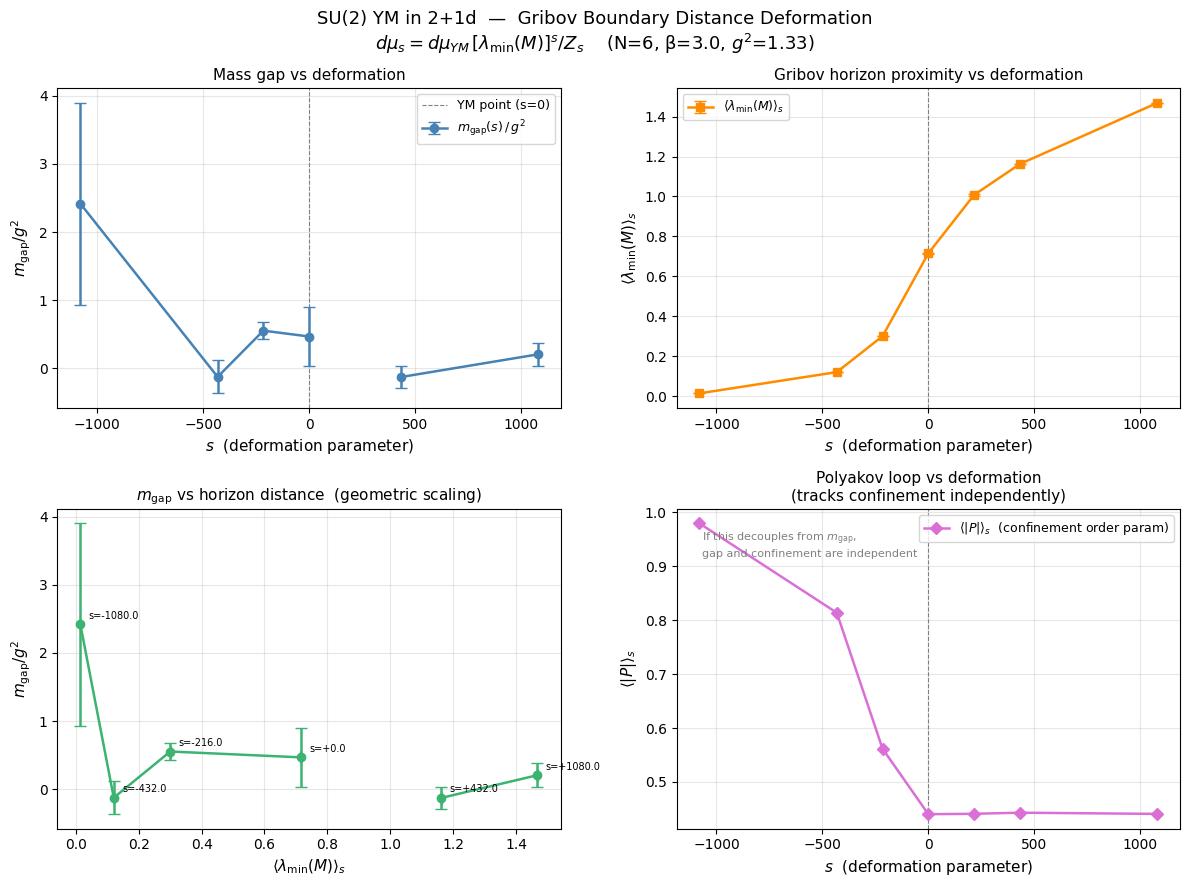

In [2]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh
from scipy.optimize import curve_fit

# ============================================================
# PARAMETERS
# ============================================================
#
# Theory: SU(2) Yang-Mills in 2+1 dimensions
# Lattice: N_x x N_y x N_t  (dirs=3, but 2 spatial + 1 temporal)
#
# Deformation: dmu_s = dmu_YM * [lambda_min(M)]^s / Z_s
#
#   s = 0  : standard Yang-Mills
#   s > 0  : suppresses near-horizon configs (measure into interior of Omega)
#   s < 0  : enhances near-horizon configs (measure toward boundary dOmega)
#
# In 2+1d, g^2 has dimension [mass], so all masses are measured in units
# of g^2. The continuum limit is beta -> inf at fixed g^2 * L = const.
# With the Wilson action, g^2 = 4 / (beta * a) in 2+1d for SU(2).
#
# ============================================================

N       = 6          # lattice size per direction (N_x = N_y = N_t = N)
dirs    = 3          # 2 spatial + 1 temporal
beta    = 3.0        # coupling: larger beta = weaker coupling / finer lattice

Ncfg          = 150  # configurations per s value (increase for production)
thermal_steps = 80   # thermalization sweeps

# s-values to scan: negative pushes toward horizon, positive away from it
s_values = np.array([-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0])

# Regularisation for lambda_min to avoid log(0)
eps_reg = 1e-6
V = N**dirs  # = 216 for N=6

# s defined as sigma/V so that sigma is the volume-intensive coupling
# sigma is what you scan; s is what enters the action
sigma_values = np.array([-5.0, -2.0, -1.0, 0.0, 1.0, 2.0, 5.0])
s_values     = sigma_values * V
# In 2+1d SU(2): g^2 = 4 / (beta * a).
# We work in units where a=1, so g2 = 4/beta.
g2 = 4.0 / beta

# ============================================================
# SU(2) UTILITIES
# ============================================================

def random_su2():
    """Haar-random SU(2) matrix."""
    a = np.random.normal(size=4)
    a /= np.linalg.norm(a)
    return np.array([
        [ a[0] + 1j*a[3],  a[2] + 1j*a[1]],
        [-a[2] + 1j*a[1],  a[0] - 1j*a[3]]
    ])

def dagger(U):
    return U.conj().T

def reunitarize(U):
    """Project back to SU(2) via SVD."""
    u, _, vh = np.linalg.svd(U)
    W = u @ vh
    # enforce det = +1
    W /= np.sqrt(np.linalg.det(W))
    return W

def small_su2(eps=0.2):
    """SU(2) matrix close to identity for local updates."""
    a = np.random.normal(size=4)
    a[0] = np.sqrt(max(1.0 - eps**2 * np.dot(a[1:], a[1:]) / np.dot(a[1:], a[1:]), 0))
    a[1:] *= eps / np.linalg.norm(a[1:])
    return np.array([
        [ a[0] + 1j*a[3],  a[2] + 1j*a[1]],
        [-a[2] + 1j*a[1],  a[0] - 1j*a[3]]
    ])

# ============================================================
# LATTICE GEOMETRY
# ============================================================

def make_sites():
    return list(itertools.product(range(N), repeat=dirs))

SITES = make_sites()
SITE_IDX = {x: i for i, x in enumerate(SITES)}

def shift(x, mu, d):
    y = list(x)
    y[mu] = (y[mu] + d) % N
    return tuple(y)

# ============================================================
# INITIAL CONFIG
# ============================================================

def init_cold():
    """Cold start: all links = identity."""
    U = {}
    for x in SITES:
        U[x] = [np.eye(2, dtype=complex) for _ in range(dirs)]
    return U

def init_hot():
    """Hot start: all links random."""
    U = {}
    for x in SITES:
        U[x] = [random_su2() for _ in range(dirs)]
    return U

# ============================================================
# WILSON ACTION  (2+1d: sum over mu < nu, dirs=3 gives 3 plaquette planes)
# ============================================================

def staple(U, x, mu):
    """Sum of staples around link (x, mu)."""
    S = np.zeros((2, 2), dtype=complex)
    for nu in range(dirs):
        if nu == mu:
            continue
        xpmu = shift(x, mu, 1)
        xpnu = shift(x, nu, 1)
        xmnu = shift(x, nu, -1)
        xpmumnu = shift(xpmu, nu, -1)

        # forward staple
        S += U[xpmu][nu] @ dagger(U[xpnu][mu]) @ dagger(U[x][nu])
        # backward staple
        S += dagger(U[xpmumnu][nu]) @ dagger(U[xmnu][mu]) @ U[xmnu][nu]
    return S

def wilson_action(U):
    S = 0.0
    for x in SITES:
        for mu in range(dirs):
            for nu in range(mu+1, dirs):
                xpmu = shift(x, mu, 1)
                xpnu = shift(x, nu, 1)
                P = U[x][mu] @ U[xpmu][nu] @ dagger(U[xpnu][mu]) @ dagger(U[x][nu])
                S += 1.0 - 0.5 * np.real(np.trace(P))
    return beta * S

def local_action(U, x, mu):
    """Action contribution from link (x,mu) only — for local Metropolis."""
    St = staple(U, x, mu)
    return -0.5 * beta * np.real(np.trace(U[x][mu] @ St))

# ============================================================
# FADDEEV-POPOV OPERATOR  M = -partial_mu D_mu
#
# In Coulomb / Landau gauge on the lattice, M is the covariant Laplacian
# in the adjoint representation.  For SU(2) the adjoint = fundamental
# (they are the same up to a basis change), so we build M in the
# fundamental representation acting on colour-vector fields psi^a(x).
#
# M^{ab}_{xy} = sum_mu [ 2 delta^{ab} delta_{xy}
#                        - U^{ab}_{x,mu}  delta_{x+mu, y}
#                        - U^{ba*}_{x-mu,mu} delta_{x-mu, y} ]
#
# This is the standard lattice Faddeev-Popov operator used in studies
# of the Gribov problem (see e.g. Cucchieri & Mendes).
# ============================================================

def faddeev_popov(U):
    """
    Build the Faddeev-Popov operator M as a (2V x 2V) Hermitian matrix.
    Eigenvalues of M characterise distance to the Gribov horizon:
      lambda_min(M) = 0  <=>  configuration is on the horizon dOmega.
    """
    V   = len(SITES)
    dim = 2 * V
    M   = np.zeros((dim, dim), dtype=complex)

    for x in SITES:
        i0 = SITE_IDX[x] * 2
        for mu in range(dirs):
            xp  = shift(x, mu,  1)
            xm  = shift(x, mu, -1)
            j0p = SITE_IDX[xp] * 2
            j0m = SITE_IDX[xm] * 2

            Uf =        U[x][mu]          # U_{x,mu}
            Ub = dagger(U[xm][mu])        # U^dag_{x-mu,mu}

            for a in range(2):
                M[i0+a, i0+a] += 2.0      # diagonal: 2 per direction
                for b in range(2):
                    M[i0+a, j0p+b] -= Uf[a, b]
                    M[i0+a, j0m+b] -= Ub[a, b]

    # symmetrise to remove floating-point asymmetry
    return 0.5 * (M + M.conj().T)

def lambda_min_FP(U):
    """Smallest eigenvalue of the Faddeev-Popov operator."""
    M    = faddeev_popov(U)
    eigs = eigvalsh(M)
    return float(np.min(np.real(eigs)))

# ============================================================
# GEOMETRIC DISTANCE TO GRIBOV HORIZON
#
# d(U) = lambda_min(M[U])  >= 0
#   = 0 on the horizon dOmega
#   > 0 inside the Gribov region Omega
#
# Deformed action contribution:
#   -s * log( lambda_min(M) + eps )
#
# This implements dmu_s = dmu_YM * [lambda_min]^s / Z_s
# ============================================================

def log_distance_to_horizon(U):
    """log( lambda_min(M) + eps ) — the geometric term in the action."""
    lmin = lambda_min_FP(U)
    return np.log(max(lmin, 0.0) + eps_reg)

# ============================================================
# METROPOLIS UPDATE
#
# Total action:  S_total = S_YM  -  s * log(lambda_min + eps)
#
# The -s prefactor means:
#   s > 0: penalises small lambda_min  -> pushes into interior of Omega
#   s < 0: rewards  small lambda_min  -> pulls toward boundary dOmega
# ============================================================

def update(U, s, eps_step=0.3):
    """One full sweep of local Metropolis updates."""
    accepted = 0
    total    = 0

    for x in SITES:
        for mu in range(dirs):
            old_link = U[x][mu].copy()

            # local Yang-Mills contribution (cheap)
            St      = staple(U, x, mu)
            S_YM_old = -0.5 * beta * np.real(np.trace(old_link @ St))

            # geometric contribution (requires full FP spectrum — expensive)
            log_d_old = log_distance_to_horizon(U) if s != 0.0 else 0.0

            # propose new link
            U[x][mu] = reunitarize(small_su2(eps_step) @ old_link)
            S_YM_new = -0.5 * beta * np.real(np.trace(U[x][mu] @ St))
            log_d_new = log_distance_to_horizon(U) if s != 0.0 else 0.0

            dS = (S_YM_new - S_YM_old) - s * (log_d_new - log_d_old)

            if dS < 0 or np.random.rand() < np.exp(-dS):
                accepted += 1
            else:
                U[x][mu] = old_link
            total += 1

    return accepted / total

# ============================================================
# OBSERVABLES
# ============================================================

# --- Plaquette (gauge invariant, all planes) ---

def all_plaquettes(U, t):
    """
    Average plaquette operator on time-slice t, summed over spatial sites
    and all plaquette orientations involving the time direction.
    Used to build the glueball-like correlator.
    """
    vals = []
    for x0 in range(N):
        for x1 in range(N):
            x = (x0, x1, t)
            # spatial plaquette (mu=0, nu=1)
            xp0 = shift(x, 0, 1)
            xp1 = shift(x, 1, 1)
            P01 = (U[x][0] @ U[xp0][1]
                   @ dagger(U[xp1][0]) @ dagger(U[x][1]))
            vals.append(np.real(np.trace(P01)))
    return np.array(vals)

def glueball_correlator(U):
    """
    Zero-momentum projected glueball-like correlator in the temporal direction.

    C(t) = sum_x < O(x,t) O(0,0) > - <O>^2

    where O(x,t) = Re Tr[ spatial plaquette at (x,t) ].

    Returns C[0..N-1].
    """
    # operator value on each time slice
    O = np.array([np.mean(all_plaquettes(U, t)) for t in range(N)])
    O0 = np.mean(O)

    C = np.zeros(N)
    for t in range(N):
        # correlator between slice 0 and slice t
        C[t] = np.mean(
            [all_plaquettes(U, 0) * all_plaquettes(U, t)]
        ) - O0**2
    return C

# --- String tension proxy via Polyakov loop ---

def polyakov_loop(U):
    """
    Average Polyakov loop: P(x) = Tr[ prod_{t=0}^{N-1} U_2(x,t) ]
    where direction 2 is the temporal direction.
    Returns the spatial average |<P>|.
    """
    vals = []
    for x0 in range(N):
        for x1 in range(N):
            P = np.eye(2, dtype=complex)
            for t in range(N):
                P = P @ U[(x0, x1, t)][2]
            vals.append(0.5 * np.abs(np.trace(P)))
    return np.mean(vals)

# ============================================================
# MASS GAP EXTRACTION
# ============================================================

def cosh_func(t, A, m, C):
    """Cosh fit: A * cosh(m*(t - N/2)) + C, appropriate for periodic BC."""
    return A * np.cosh(m * (t - N / 2.0)) + C

def exp_func(t, A, m):
    return A * np.exp(-m * t)

def extract_mass(C):
    """
    Fit C(t) to extract the mass gap.
    Uses cosh fit (correct for periodic BC) with fallback to exponential.
    Only fits t = 1 .. N//2  to avoid wrap-around contamination.
    """
    t_arr = np.arange(N, dtype=float)
    t_fit = t_arr[1: N//2 + 1]
    C_fit = C[1: N//2 + 1]

    if np.any(np.isnan(C_fit)) or np.all(C_fit <= 0):
        return np.nan

    # cosh fit
    try:
        p0 = [C_fit[0], 0.5, 0.0]
        popt, pcov = curve_fit(cosh_func, t_fit, C_fit,
                               p0=p0, maxfev=10000,
                               bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]))
        if np.all(np.isfinite(np.sqrt(np.diag(pcov)))):
            return popt[1]
    except Exception:
        pass

    # exponential fallback
    try:
        popt, _ = curve_fit(exp_func, t_fit, np.abs(C_fit),
                            p0=(abs(C_fit[0]), 0.5), maxfev=5000)
        return popt[1]
    except Exception:
        return np.nan

# ============================================================
# MAIN SIMULATION LOOP
# ============================================================

results = {
    's':           [],
    'm_over_g2':   [],   # m_gap / g^2  (dimensionless in 2+1d)
    'lmin_avg':    [],   # <lambda_min(M)>_s
    'lmin_err':    [],
    'm_err':       [],
    'polyakov':    [],
    'accept':      [],
}

print(f"\nSU(2) Yang-Mills in 2+1d  |  N={N}  beta={beta}  g^2={g2:.3f}")
print(f"Ncfg={Ncfg}  thermal={thermal_steps}")
print(f"Deformation: S_total = S_YM - s * log(lambda_min(M) + eps)")
print("="*60)

for s in s_values:

    print(f"\n  s = {s:+.2f}")
    print(  "  ----------")

    U = init_hot()

    # thermalize
    acc_therm = []
    for step in range(thermal_steps):
        ar = update(U, s)
        acc_therm.append(ar)
    print(f"  Thermalisation acceptance: {np.mean(acc_therm):.2f}")

    # measurement phase
    C_samples    = []
    lmin_samples = []
    poly_samples = []
    acc_meas     = []

    for cfg in range(Ncfg):
        ar = update(U, s)
        acc_meas.append(ar)

        C_samples.append(glueball_correlator(U))
        lmin_samples.append(lambda_min_FP(U))
        poly_samples.append(polyakov_loop(U))

        if (cfg + 1) % 30 == 0:
            print(f"    cfg {cfg+1}/{Ncfg}  "
                  f"lmin={lmin_samples[-1]:.4f}  "
                  f"accept={ar:.2f}")

    C_arr    = np.array(C_samples)      # shape (Ncfg, N)
    lmin_arr = np.array(lmin_samples)

    # --- mass gap from averaged correlator ---
    C_avg = np.mean(C_arr, axis=0)
    m_lat = extract_mass(C_avg)

    # jackknife error on mass
    m_jack = []
    for k in range(Ncfg):
        C_jk = np.mean(np.delete(C_arr, k, axis=0), axis=0)
        m_jack.append(extract_mass(C_jk))
    m_jack  = np.array([x for x in m_jack if not np.isnan(x)])
    m_err   = np.sqrt((Ncfg - 1) * np.var(m_jack)) if len(m_jack) > 1 else np.nan

    # dimensionless mass in units of g^2
    m_over_g2     = m_lat / g2 if not np.isnan(m_lat) else np.nan
    m_err_over_g2 = m_err / g2 if not np.isnan(m_err) else np.nan

    lmin_mean = np.mean(lmin_arr)
    lmin_err  = np.std(lmin_arr) / np.sqrt(Ncfg)

    results['s'].append(s)
    results['m_over_g2'].append(m_over_g2)
    results['m_err'].append(m_err_over_g2)
    results['lmin_avg'].append(lmin_mean)
    results['lmin_err'].append(lmin_err)
    results['polyakov'].append(np.mean(poly_samples))
    results['accept'].append(np.mean(acc_meas))

    print(f"  m_gap/g^2 = {m_over_g2:.4f} ± {m_err_over_g2:.4f}")
    print(f"  <lambda_min> = {lmin_mean:.4f} ± {lmin_err:.4f}")
    print(f"  <|Polyakov|> = {np.mean(poly_samples):.4f}")
    print(f"  Mean acceptance = {np.mean(acc_meas):.2f}")

# ============================================================
# PLOTS
# ============================================================

s_arr    = np.array(results['s'])
m_arr    = np.array(results['m_over_g2'])
m_err    = np.array(results['m_err'])
lmin_arr = np.array(results['lmin_avg'])
lmin_err = np.array(results['lmin_err'])
poly_arr = np.array(results['polyakov'])

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(
    f"SU(2) YM in 2+1d  —  Gribov Boundary Distance Deformation\n"
    f"$d\\mu_s = d\\mu_{{YM}}\\,[\\lambda_{{\\min}}(M)]^s / Z_s$"
    f"    (N={N}, β={beta}, $g^2$={g2:.2f})",
    fontsize=13
)

# ── Panel 1: mass gap vs s ──────────────────────────────────
ax = axes[0, 0]
ax.axvline(0, color='gray', lw=0.8, ls='--', label='YM point (s=0)')
ax.errorbar(s_arr, m_arr, yerr=m_err,
            fmt='o-', color='steelblue', capsize=4, lw=1.8,
            label=r'$m_\mathrm{gap}(s)\,/\,g^2$')
ax.set_xlabel('$s$  (deformation parameter)', fontsize=11)
ax.set_ylabel(r'$m_\mathrm{gap} / g^2$', fontsize=11)
ax.set_title(r'Mass gap vs deformation', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: lambda_min vs s ────────────────────────────────
ax = axes[0, 1]
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.errorbar(s_arr, lmin_arr, yerr=lmin_err,
            fmt='s-', color='darkorange', capsize=4, lw=1.8,
            label=r'$\langle\lambda_{\min}(M)\rangle_s$')
ax.set_xlabel('$s$  (deformation parameter)', fontsize=11)
ax.set_ylabel(r'$\langle\lambda_{\min}(M)\rangle_s$', fontsize=11)
ax.set_title('Gribov horizon proximity vs deformation', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 3: m/g^2 vs lambda_min  (the key geometric plot) ──
ax = axes[1, 0]
# sort by lmin for a clean curve
order = np.argsort(lmin_arr)
ax.errorbar(lmin_arr[order], m_arr[order],
            xerr=lmin_err[order], yerr=m_err[order],
            fmt='o-', color='mediumseagreen', capsize=4, lw=1.8)
# annotate each point with its s value
for i in order:
    ax.annotate(f's={s_arr[i]:+.1f}',
                (lmin_arr[i], m_arr[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=7)
ax.set_xlabel(r'$\langle\lambda_{\min}(M)\rangle_s$', fontsize=11)
ax.set_ylabel(r'$m_\mathrm{gap} / g^2$', fontsize=11)
ax.set_title(r'$m_\mathrm{gap}$ vs horizon distance  (geometric scaling)', fontsize=11)
ax.grid(True, alpha=0.3)

# ── Panel 4: Polyakov loop vs s ─────────────────────────────
ax = axes[1, 1]
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.plot(s_arr, poly_arr, 'D-', color='orchid', lw=1.8,
        label=r'$\langle|P|\rangle_s$  (confinement order param)')
ax.set_xlabel('$s$  (deformation parameter)', fontsize=11)
ax.set_ylabel(r'$\langle|P|\rangle_s$', fontsize=11)
ax.set_title('Polyakov loop vs deformation\n(tracks confinement independently)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate('If this decouples from $m_\\mathrm{gap}$,\ngap and confinement are independent',
            xy=(0.05, 0.85), xycoords='axes fraction', fontsize=8,
            color='gray')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/gribov_2d1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved.")

# ============================================================
# SUMMARY TABLE
# ============================================================

print("\n" + "="*60)
print(f"{'s':>6}  {'m/g²':>10}  {'±':>8}  {'<λmin>':>10}  {'±':>8}  {'|P|':>8}")
print("-"*60)
for i, s in enumerate(results['s']):
    print(f"{s:>6.2f}  "
          f"{results['m_over_g2'][i]:>10.4f}  "
          f"{results['m_err'][i]:>8.4f}  "
          f"{results['lmin_avg'][i]:>10.4f}  "
          f"{results['lmin_err'][i]:>8.4f}  "
          f"{results['polyakov'][i]:>8.4f}")
print("="*60)
print(f"\nKarabali-Nair prediction (SU(2), 2+1d): m/g² ≈ 0.74")
print("(benchmark for s=0 value)")

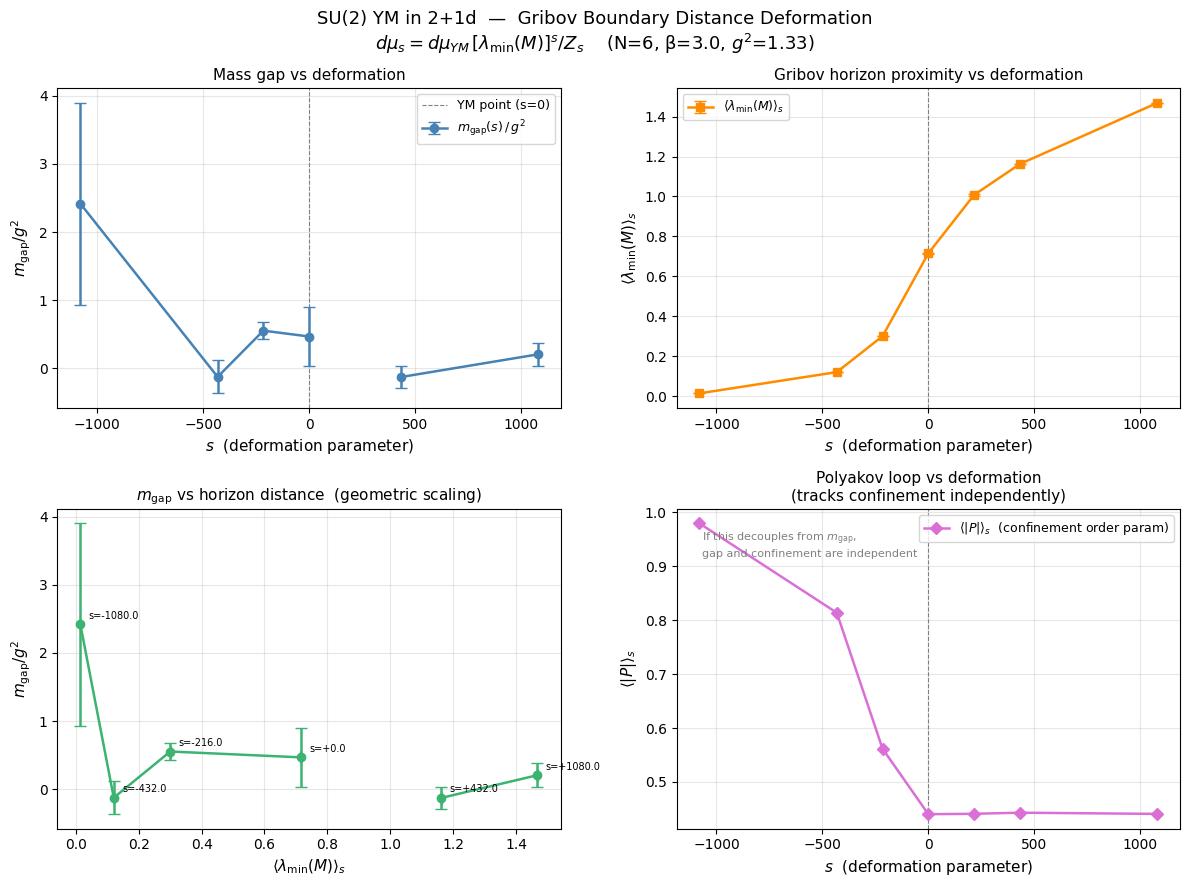


Plot saved.


In [5]:
s_arr    = np.array(results['s'])
m_arr    = np.array(results['m_over_g2'])
m_err    = np.array(results['m_err'])
lmin_arr = np.array(results['lmin_avg'])
lmin_err = np.array(results['lmin_err'])
poly_arr = np.array(results['polyakov'])

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(
    f"SU(2) YM in 2+1d  —  Gribov Boundary Distance Deformation\n"
    f"$d\\mu_s = d\\mu_{{YM}}\\,[\\lambda_{{\\min}}(M)]^s / Z_s$"
    f"    (N={N}, β={beta}, $g^2$={g2:.2f})",
    fontsize=13
)

# ── Panel 1: mass gap vs s ──────────────────────────────────
ax = axes[0, 0]
ax.axvline(0, color='gray', lw=0.8, ls='--', label='YM point (s=0)')
ax.errorbar(s_arr, m_arr, yerr=m_err,
            fmt='o-', color='steelblue', capsize=4, lw=1.8,
            label=r'$m_\mathrm{gap}(s)\,/\,g^2$')
ax.set_xlabel('$s$  (deformation parameter)', fontsize=11)
ax.set_ylabel(r'$m_\mathrm{gap} / g^2$', fontsize=11)
ax.set_title(r'Mass gap vs deformation', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: lambda_min vs s ────────────────────────────────
ax = axes[0, 1]
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.errorbar(s_arr, lmin_arr, yerr=lmin_err,
            fmt='s-', color='darkorange', capsize=4, lw=1.8,
            label=r'$\langle\lambda_{\min}(M)\rangle_s$')
ax.set_xlabel('$s$  (deformation parameter)', fontsize=11)
ax.set_ylabel(r'$\langle\lambda_{\min}(M)\rangle_s$', fontsize=11)
ax.set_title('Gribov horizon proximity vs deformation', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 3: m/g^2 vs lambda_min  (the key geometric plot) ──
ax = axes[1, 0]
# sort by lmin for a clean curve
order = np.argsort(lmin_arr)
ax.errorbar(lmin_arr[order], m_arr[order],
            xerr=lmin_err[order], yerr=m_err[order],
            fmt='o-', color='mediumseagreen', capsize=4, lw=1.8)
# annotate each point with its s value
for i in order:
    ax.annotate(f's={s_arr[i]:+.1f}',
                (lmin_arr[i], m_arr[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=7)
ax.set_xlabel(r'$\langle\lambda_{\min}(M)\rangle_s$', fontsize=11)
ax.set_ylabel(r'$m_\mathrm{gap} / g^2$', fontsize=11)
ax.set_title(r'$m_\mathrm{gap}$ vs horizon distance  (geometric scaling)', fontsize=11)
ax.grid(True, alpha=0.3)

# ── Panel 4: Polyakov loop vs s ─────────────────────────────
ax = axes[1, 1]
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.plot(s_arr, poly_arr, 'D-', color='orchid', lw=1.8,
        label=r'$\langle|P|\rangle_s$  (confinement order param)')
ax.set_xlabel('$s$  (deformation parameter)', fontsize=11)
ax.set_ylabel(r'$\langle|P|\rangle_s$', fontsize=11)
ax.set_title('Polyakov loop vs deformation\n(tracks confinement independently)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate('If this decouples from $m_\\mathrm{gap}$,\ngap and confinement are independent',
            xy=(0.05, 0.85), xycoords='axes fraction', fontsize=8,
            color='gray')

plt.tight_layout()
plt.savefig('gribov_2d1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved.")